# 01c - worked example (standalone): Milton . Within . Retail & Leisure

Refined single panel for assembly into Figure 1c. Plot-only (reads 00's cached baseline + metrics).

Tweaks vs the generic `01_design.ipynb` loop:
1. baseline label is **"Baseline"** (not "SARIMAX baseline");
2. legend sits in **top headroom** so it never overlaps the curves;
3. the **trough** annotation sits in **bottom headroom**, clear of the x-axis labels;
4. figure size fixed to **(7, 3.5)**.

Output -> `results/npj_100mi/figure1c_milton_within_retail.{pdf,png}`.

In [1]:
import pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, DayLocator
warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],
    'font.size':8,'axes.titlesize':8,'axes.labelsize':8,'xtick.labelsize':7,'ytick.labelsize':7,
    'legend.fontsize':7,'axes.linewidth':0.6,'axes.spines.top':False,'axes.spines.right':False,
    'savefig.dpi':300,'savefig.bbox':'tight','pdf.fonttype':42,'ps.fonttype':42,
})

In [12]:
# Path resolution + this panel's selection
def find_project_root(start):
    sentinel = pathlib.Path('results')/'npj_100mi'/'regional_data'/'regional_metrics_summary_100mi.csv'
    for p in [start, *start.parents]:
        if (p/sentinel).exists():
            return p
    raise FileNotFoundError(f'Run 00 first; cannot find {sentinel} from {start}')

PROJECT_ROOT = find_project_root(pathlib.Path.cwd())
REGIONAL = PROJECT_ROOT/'results'/'npj_100mi'/'regional_data'
OUT_DIR  = PROJECT_ROOT/'results'/'npj_100mi'; OUT_DIR.mkdir(parents=True, exist_ok=True)

HKEY, FLOW, CAT = 'milton', 'within', 'Retail & Leisure'
LANDING = pd.Timestamp('2024-10-09')
FIGSIZE = (6.5, 2.)                       # fixed per request (nudge slightly if needed)

def category_to_filename(c): return c.replace(' & ','_and_').replace(' ','_')
METRICS = pd.read_csv(REGIONAL/'regional_metrics_summary_100mi.csv')
print('REGIONAL exists:', REGIONAL.exists())

REGIONAL exists: True


saved -> figure1c_milton_within_retail (.pdf/.png)


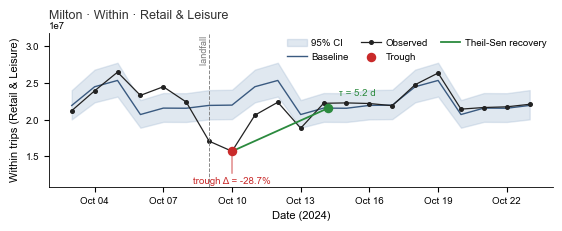

In [13]:
def worked_panel(ax):
    bl = pd.read_csv(REGIONAL/HKEY/f'baseline_{FLOW}_{category_to_filename(CAT)}.csv',
                     index_col=0, parse_dates=True)
    row = METRICS[(METRICS.hurricane==HKEY)&(METRICS.flow_type==FLOW)&(METRICS.category==CAT)].iloc[0]
    recovery_days = row['recovery_days']

    # trough = min relative deviation in [landing, landing+10]
    rd = (bl['y_true']-bl['y_pred'])/bl['y_pred']*100.0
    dw = rd.loc[LANDING:LANDING+pd.Timedelta(days=10)]
    trough_date, trough_drop = dw.idxmin(), dw.min()
    trough_val = bl.loc[trough_date, 'y_true']

    win = bl.loc[LANDING-pd.Timedelta(days=10):LANDING+pd.Timedelta(days=14)]

    ax.fill_between(win.index, win['ci_lower'], win['ci_upper'], color='#9bb4cf', alpha=0.30, label='95% CI')
    ax.plot(win.index, win['y_pred'], color='#3a5a80', linewidth=1.0, label='Baseline')          # <- renamed
    ax.plot(win.index, win['y_true'], color='#222', linewidth=0.9, marker='o', markersize=2.6, label='Observed')
    ax.scatter([trough_date], [trough_val], s=34, color='#c92a2a', zorder=5, label='Trough')

    if pd.notna(recovery_days) and recovery_days > 0:
        recovery_date = LANDING + pd.Timedelta(days=float(recovery_days))
        rec_val = bl.loc[bl.index.asof(recovery_date), 'y_pred']
        ax.plot([trough_date, recovery_date], [trough_val, rec_val], color='#2b8a3e', linewidth=1.3,
                label='Theil-Sen recovery')
        ax.scatter([recovery_date], [rec_val], s=34, color='#2b8a3e', zorder=5)
        ax.annotate(f'τ = {recovery_days:.1f} d', xy=(recovery_date, rec_val),
                    xytext=(8, 9), textcoords='offset points', fontsize=7, color='#2b8a3e')

    # headroom: extra space at TOP (for the legend) and BOTTOM (for the trough label)
    ymin = float(min(win['y_true'].min(), win['ci_lower'].min()))
    ymax = float(max(win['y_true'].max(), win['ci_upper'].max()))
    span = ymax - ymin
    ax.set_ylim(ymin - 0.40*span, ymax + 0.34*span)

    # landfall marker (rotated label hanging from the top, left of the legend block)
    ax.axvline(LANDING, color='#888', linestyle='--', linewidth=0.7)
    ax.text(LANDING, ax.get_ylim()[1], 'landfall ', rotation=90, ha='right', va='top',
            fontsize=6.5, color='#777')

    # trough label -> into the bottom headroom, clear of the x-axis labels
    ax.annotate(f'trough Δ = {trough_drop:.1f}%', xy=(trough_date, trough_val),
                xytext=(0, -18), textcoords='offset points', ha='center', va='top',
                fontsize=7, color='#c92a2a',
                arrowprops=dict(arrowstyle='-', color='#c92a2a', lw=0.6, shrinkA=0, shrinkB=2))

    # legend -> top headroom, two rows, kept off the curves
    ax.legend(loc='upper right', ncol=3, frameon=False, fontsize=7,
              columnspacing=1.3, handletextpad=0.5, borderaxespad=0.2)

    ax.set_xlabel('Date (2024)'); ax.set_ylabel(f'Within trips ({CAT})')
    ax.xaxis.set_major_locator(DayLocator(interval=3)); ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
    plt.setp(ax.get_xticklabels(), rotation=0)
    ax.set_title('Milton · Within · Retail & Leisure', loc='left', fontsize=9, color='#333', pad=2)

fig, ax = plt.subplots(figsize=FIGSIZE)
worked_panel(ax)
fig.savefig(OUT_DIR/'figure1c_milton_within_retail.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR/'figure1c_milton_within_retail.png', dpi=300, bbox_inches='tight')
print('saved -> figure1c_milton_within_retail (.pdf/.png)')
plt.show()